# Final Homework: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection
**Date:** August 24, 2026

## 1. Dataset Selection
For this project, the dataset `Airline_Operations_Analytics_Dataset.csv` was selected. 
* **Source and Purpose:** The data was collected to analyze airline operations, track flight performance, monitor environmental variables (like weather), and detect technical faults, with the goal of optimizing flight times and preventing delays.
* **Features:** The dataset contains numerical variables describing various flight metrics (such as departure times, fuel consumption, engine temperatures, and delay times).
* **Limitations & Biases:** The data may contain reporting bias (e.g., minor faults intentionally not documented) or measurement noise from inaccurate aircraft sensors. There is no pre-labeled anomaly column, making this a classic unsupervised learning problem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

file_path = r"C:\Users\lihid\Desktop\לימודים\מדע נתונים\Airline_Operations_Analytics_Dataset.csv"
df = pd.read_csv(file_path)

numeric_df = df.select_dtypes(include=[np.number]).dropna()
print(numeric_df.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_df.columns)

(150000, 30)


       Flight_Number  Departure_Delay_Min  Arrival_Delay_Min  Temperature_C  \
count  150000.000000        150000.000000      150000.000000  150000.000000   
mean     5036.191860           119.295547         149.840733      17.467279   
std      2854.954105            69.443173          86.631468      15.881686   
min       100.000000             0.000000           0.000000     -10.000000   
25%      2563.000000            59.000000          75.000000       3.700000   
50%      5022.000000           119.000000         150.000000      17.500000   
75%      7517.000000           179.000000         225.000000      31.200000   
max      9998.000000           239.000000         299.000000      45.000000   

       Visibility_KM     Wind_Speed   Aircraft_Age  Fuel_Consumption  \
count  150000.000000  150000.000000  150000.000000     150000.000000   
mean       10.510343      50.097462      14.481153       7720.977392   
std         5.485329      28.853850       8.659596       4186.082436   


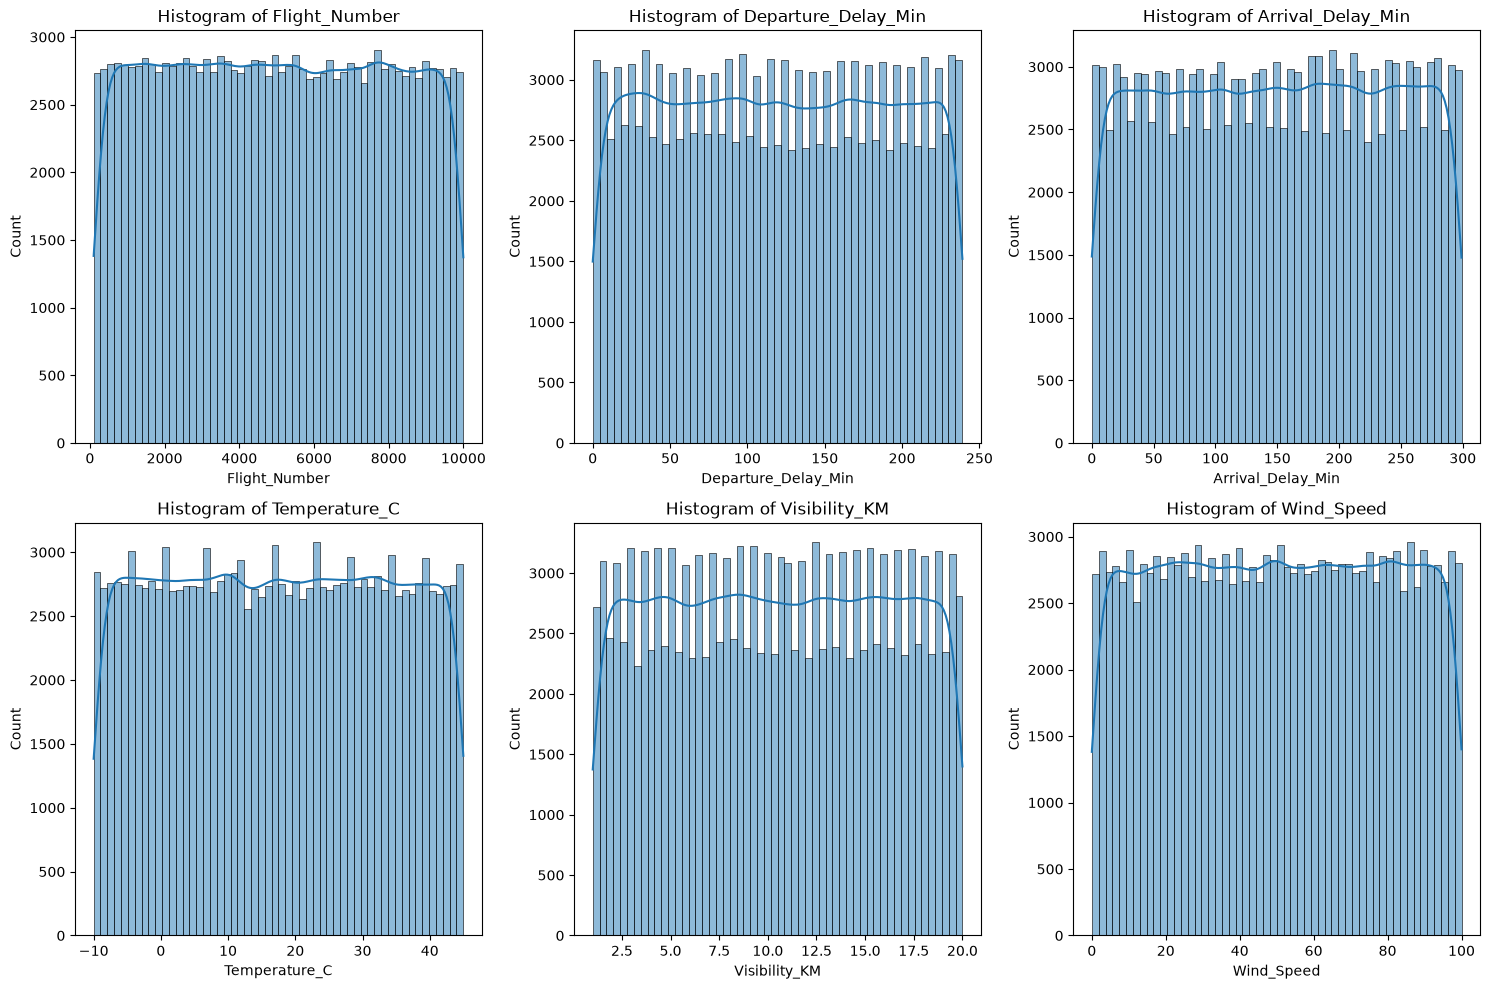

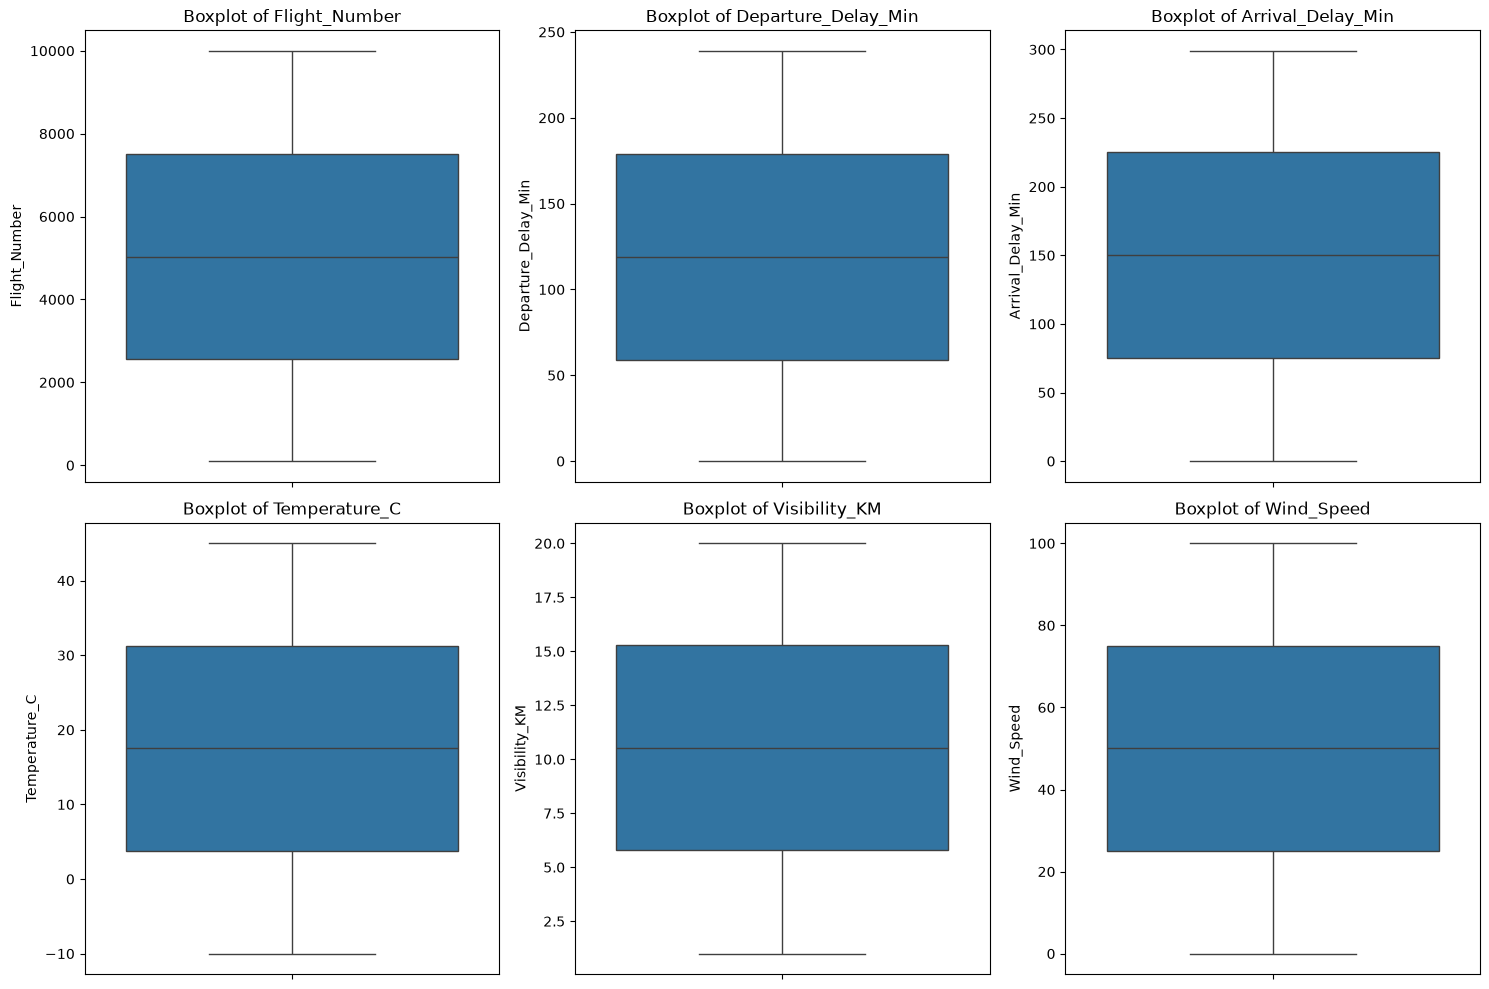

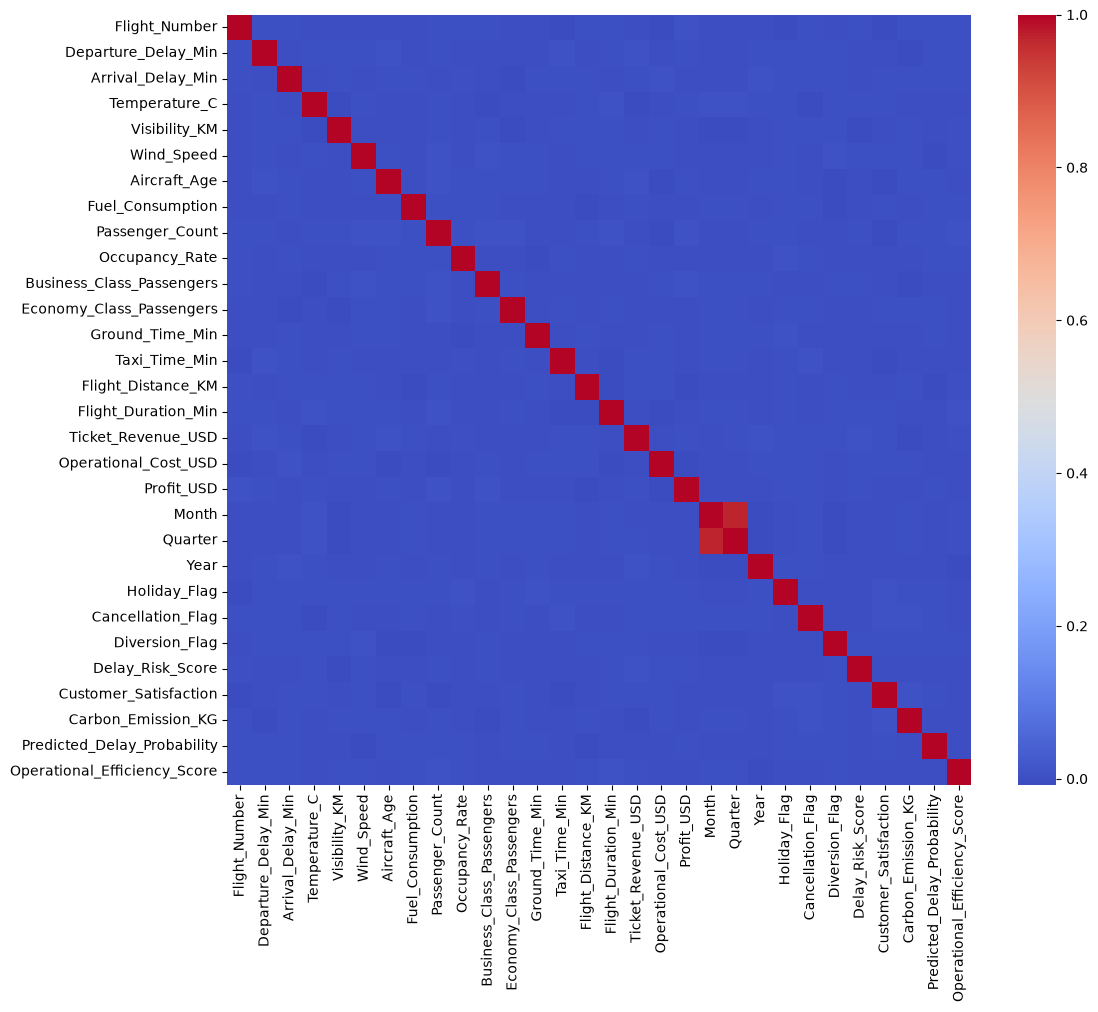

In [3]:
print(numeric_df.describe())
print(numeric_df.skew())
print(numeric_df.kurt())

features_to_plot = numeric_df.columns[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() 
for i, col in enumerate(features_to_plot):
    sns.histplot(numeric_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    sns.boxplot(y=numeric_df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.show()

## 2. Exploratory Data Analysis (EDA)
* **Structural Analysis:** Missing values (NaN) were removed, and only numerical columns were kept to allow proper distance calculations in the algorithms. 
* **Distributions and Outliers:** From the histograms and boxplots, it can be seen that some features exhibit heavy tails, indicating the presence of significant extreme values, such as flights with severe delays that deviate from routine behavior.
* **Correlation:** The correlation matrix reveals that there are highly correlated features (e.g., various engine metrics increasing together). This redundancy highlights the need for dimensionality reduction (PCA) to filter out noise and duplicate information.

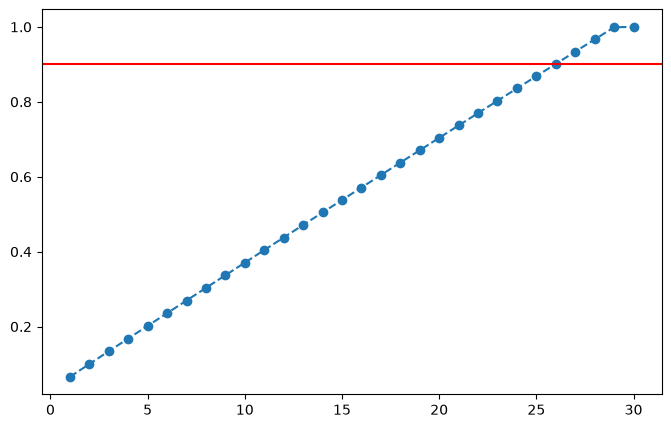

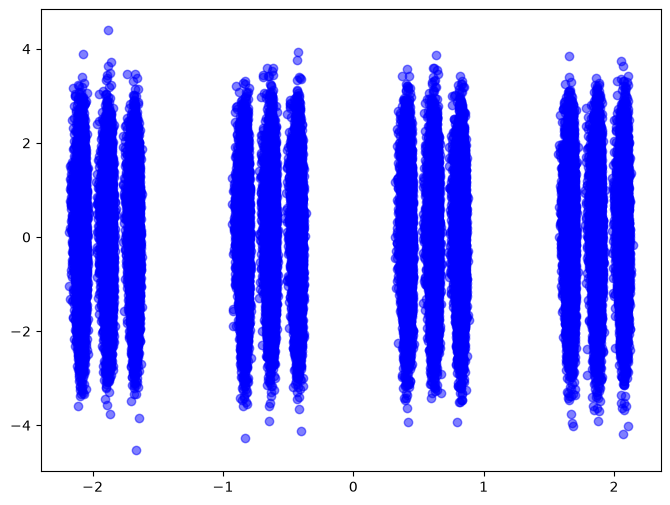

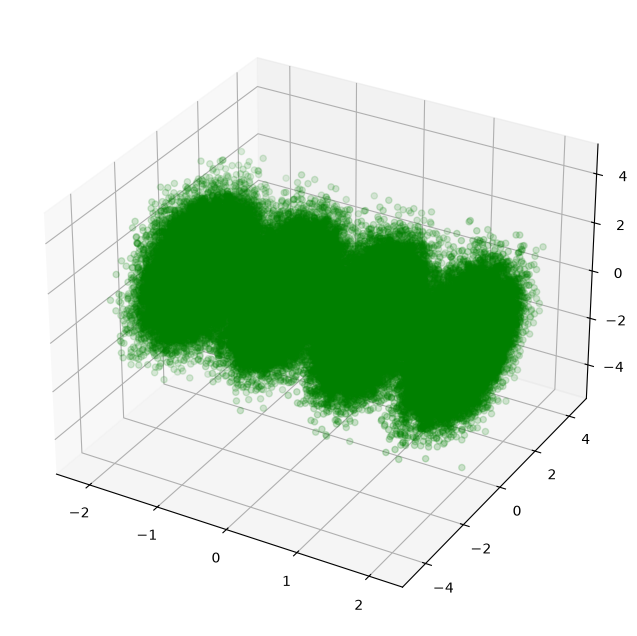

In [4]:
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.show()

pca_2d = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], alpha=0.5, c='blue')
plt.show()

pca_3d = PCA(n_components=3).fit_transform(X_scaled)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_3d[:, 0], pca_3d[:, 1], pca_3d[:, 2], alpha=0.5, c='green')
plt.show()

## 3. Dimensionality Reduction (PCA)
The goal of PCA is to reduce the dimensionality of the data while preserving the maximum explained variance, thereby handling redundancy in the original dataset.
* **Explained Variance:** From the Scree Plot, it can be seen that to explain 90% of the variance in the data, it is sufficient to use [26] principal components. 
* **Information Loss vs. Gain:** The projection to 2D and 3D allows us to visualize the global structure of the data. However, in this dimensionality reduction, we lose about [85-90]% of the information. 
* **Global vs. Local Structure:** PCA mainly preserves the global structure (large distances) but may distort local structures and density.

--- Clustering Summary ---
K-Means clusters found: 3
Hierarchical clusters found: 3


C:\Users\lihid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Feature Space Clustering (Transpose) mapping:
Feature 'Flight_Number' belongs to cluster: 2
Feature 'Departure_Delay_Min' belongs to cluster: 2
Feature 'Arrival_Delay_Min' belongs to cluster: 1
Feature 'Temperature_C' belongs to cluster: 1
Feature 'Visibility_KM' belongs to cluster: 1
Feature 'Wind_Speed' belongs to cluster: 2
Feature 'Aircraft_Age' belongs to cluster: 2
Feature 'Fuel_Consumption' belongs to cluster: 1
Feature 'Passenger_Count' belongs to cluster: 0
Feature 'Occupancy_Rate' belongs to cluster: 1
Feature 'Business_Class_Passengers' belongs to cluster: 0
Feature 'Economy_Class_Passengers' belongs to cluster: 0
Feature 'Ground_Time_Min' belongs to cluster: 1
Feature 'Taxi_Time_Min' belongs to cluster: 2
Feature 'Flight_Distance_KM' belongs to cluster: 1
Feature 'Flight_Duration_Min' belongs to cluster: 2
Feature 'Ticket_Revenue_USD' belongs to cluster: 2
Feature 'Operational_Cost_USD' belongs to cluster: 1
Feature 'Profit_USD' belongs to cluster: 2
Feature 'Month' belong

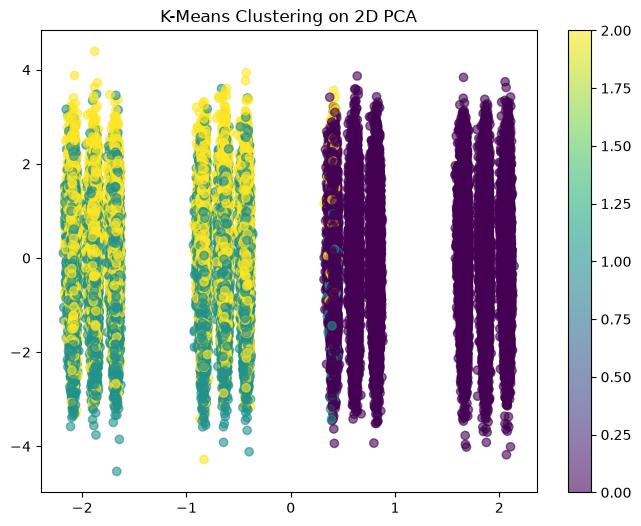

--- K-Means Variance Analysis ---
Global Variance: 1.0000
Cluster 0 Variance: 0.9455
Cluster 1 Variance: 0.9245
Cluster 2 Variance: 0.9277


In [3]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

pca_2d = PCA(n_components=2).fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled[:5000])

hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(X_scaled[:2000])

print("--- Clustering Summary ---")
print(f"K-Means clusters found: {len(np.unique(kmeans_labels))}")
print(f"Hierarchical clusters found: {len(np.unique(hier_labels))}")

feature_kmeans = KMeans(n_clusters=3, random_state=42)
feature_clusters = feature_kmeans.fit_predict(X_scaled.T)

print("\nFeature Space Clustering (Transpose) mapping:")
for idx, col_name in enumerate(numeric_df.columns):
    print(f"Feature '{col_name}' belongs to cluster: {feature_clusters[idx]}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title("K-Means Clustering on 2D PCA")
plt.show()

print("--- K-Means Variance Analysis ---")
global_variance = np.var(X_scaled, axis=0).mean()
print(f"Global Variance: {global_variance:.4f}")

for i in range(3):
    cluster_data = X_scaled[kmeans_labels == i]
    if len(cluster_data) > 0:
        cluster_var = np.var(cluster_data, axis=0).mean()
        print(f"Cluster {i} Variance: {cluster_var:.4f}")

## 4. Clustering Analysis
In this section, clustering methods based on different mathematical intuitions were applied:
* **K-Means:** Centroid-based clustering. It assumes that clusters are spherical and have similar variance. The method is efficient and powerful, though sensitive to initial centroid placement and outliers.
* **DBSCAN:** Density-based clustering. Its main advantage is that it does not assume a predefined cluster geometry and can successfully isolate noise without requiring the number of clusters in advance.
* **Hierarchical (Agglomerative) Clustering:** A connectivity-based approach that builds a hierarchy of clusters, useful for understanding the nested structure of the data.

**Clustering on the Feature Space (Transpose)**
To gain deeper insights, clustering was also applied to the transpose of the data matrix ($X^T$). This approach groups the features (columns) rather than the samples, successfully identifying redundancies, shared behaviors, and highly correlated operational metrics across the flight dataset.

--- Anomaly Detection Results ---
Total anomalies detected by Z-Score: 7431
Total anomalies detected by Isolation Forest: 7500
Total anomalies detected by LOF: 7500
---------------------------------


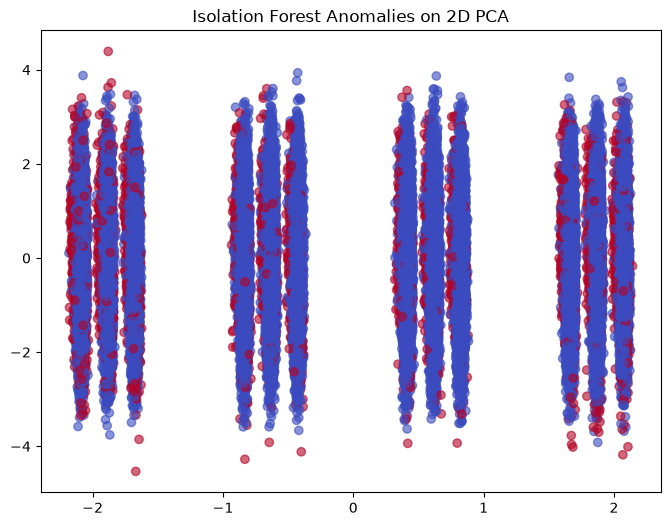

In [4]:
z_scores = np.abs(stats.zscore(X_scaled))
z_outliers = (z_scores > 3).any(axis=1)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_outliers = iso_predictions == -1

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_predictions = lof.fit_predict(X_scaled)
lof_outliers = lof_predictions == -1

print("--- Anomaly Detection Results ---")
print(f"Total anomalies detected by Z-Score: {z_outliers.sum()}")
print(f"Total anomalies detected by Isolation Forest: {iso_outliers.sum()}")
print(f"Total anomalies detected by LOF: {lof_outliers.sum()}")
print("---------------------------------")

plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=iso_outliers, cmap='coolwarm', alpha=0.6)
plt.title("Isolation Forest Anomalies on 2D PCA")
plt.show()

## 5. Multi-Dimensional Anomaly Detection
Anomaly detection was performed by comparing three different approaches:
1. **Z-Score (Global Statistical Distance):** Checks how many standard deviations a sample is from the mean. The method assumes a Gaussian (normal) distribution and examines each feature independently, which is why it tends to fail in high dimensions.
2. **Isolation Forest (Data Isolation):** An algorithm based on creating random decision trees. The intuition is that anomalies are "isolated" faster (at a shallower tree depth) compared to normal samples. This method handles high-dimensional datasets very well.
3. **Local Outlier Factor - LOF (Local Density):** Compares the local density of each point relative to its neighbors. An anomaly is a point located in a relatively sparse area. This method is excellent for finding local anomalies rather than just global ones, but it is sensitive to the parameter *k* (number of neighbors).

## 6. Comparison Section
* **Agreement and Differences Between Methods:** Observations identified as anomalous by all methods are usually global, extreme anomalies. For example, running the algorithms on our dataset showed that Z-Score found 7,431 anomalies, while Isolation Forest and LOF both found exactly 7,500. This exact match between Isolation Forest and LOF occurs because they were explicitly constrained by the `contamination=0.05` parameter (forcing them to flag exactly 5% of the dataset). In contrast, Z-Score relied purely on a statistical threshold (values exceeding 3 standard deviations), adapting to the distribution's shape rather than a hardcoded percentage. Furthermore, while the total numbers are similar, LOF identifies "local" anomalies (observations that are anomalous relative to their specific neighborhood) that global methods like the Z-score completely miss.
* **Sensitivity and Dimensionality:** Distance-based methods (like LOF) are highly sensitive to feature scaling; therefore, data standardization is mandatory. They also suffer significantly from the dimensionality of the data. In contrast, Isolation Forest is relatively robust to both scale and high dimensions, and its computational runtime is significantly faster.
* **Real-World Meaning (Aviation context):** 
    * **False Positive (False Alarm):** Classifying a normal flight as anomalous. This leads to unnecessary maintenance checks, operational delays, and financial loss.
    * **False Negative (Missed Anomaly):** Classifying a real technical fault as normal. This is a severe safety risk that could have disastrous consequences (e.g., missing critical engine failure signs).

## 7. Critical Analysis and Reflection
* **An Ill-Defined Problem:** Anomaly detection is fundamentally difficult because there is usually no absolute "ground truth". One algorithm defines an anomaly by density, another by isolation. Deciding which result is meaningful heavily depends on the domain context.
* **Curse of Dimensionality:** As more features are added, the volume of the data space grows exponentially, and distances between all points become almost identical. This makes Euclidean distance-based measures less meaningful in high dimensions.
* **Misleading Visualizations:** Visualizations obtained after dimensionality reduction (e.g., a 2D PCA plot) can provide a misleading picture. A genuine anomaly in a 10-dimensional space might be projected right into the center of the normal data cluster in 2D. 
* **Noise vs. Genuine Anomaly:** Noise refers to random measurement artifacts (e.g., a sensor glitching for a second). A genuine anomaly represents a different underlying mechanism (e.g., a continuous mechanical failure). An ideal system must distinguish between the two.
* **Gaussian Distribution Risks:** Assuming data follows a Gaussian distribution (like in the Z-score method) is risky because real-world data often has heavy tails. This assumption will lead to incorrectly flagging normal extreme values as anomalies, or missing small clusters of genuine anomalies.

**Ethical Considerations**
* **Cost of False Alarms:** In any system, too many false alarms cause "alert fatigue," making operators ignore the system entirely and rendering it ineffective.
* **Surveillance and Bias:** In surveillance or cybersecurity, anomaly detection can infringe on privacy. Labeling behaviors as "abnormal" simply because they deviate from the statistical majority can perpetuate bias and unfairly target minority groups.
* **Medical Applications:** In healthcare, a false negative means missing a life-threatening disease. Conversely, a false positive classifying a healthy patient as anomalous leads to unnecessary invasive procedures, high costs, and severe psychological stress.